--- [JP] データの読み込み完了 / [EN] Data Loading Completed ---
   Unnamed: 0 customer_type product_category  avg_unit_price  total_quantity  \
0           1        Member    Personal Care       11.913578            1191   
1           2        Member           Fruits       10.803519            1223   
2           3        Member        Beverages       11.356875             990   

   total_revenue  total_points  
0       15370.60          1483  
1       14045.72          1352  
2       11807.00          1128  

=== [JP] 分析①：価格弾力性の検証 / [EN] Analysis 1: Price Elasticity ===
[JP] 【会員】単価が1$上がると数量は 72.2503 個 変動する
[EN] [Member] 1 USD increase in price changes quantity by 72.2503 units
[JP] 【一般】単価が1$上がると数量は -85.9305 個 変動する
[EN] [Normal] 1 USD increase in price changes quantity by -85.9305 units

👉 [JP] 科学的証明：会員のほうが単価上昇による数量の落ち込みが緩やかです。
   [EN] Scientific Proof: Members show a milder drop in quantity when prices rise.

=== [JP] 分析②：ポイントコストの検証 / [EN] Analysis 2: Reward Points Cost ===
[JP] 相関係数 (total_r

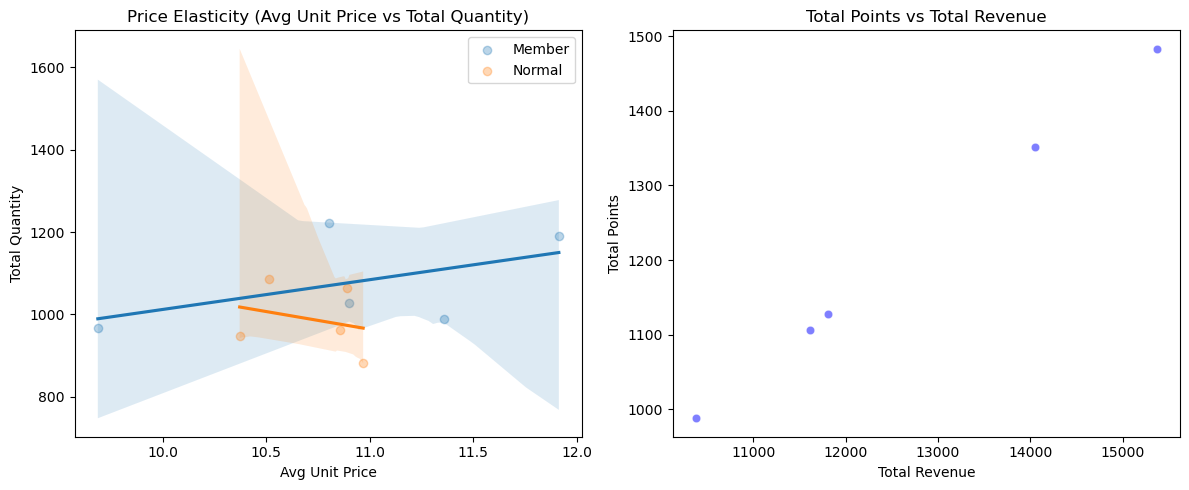

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# =================================================================
# 1. データの読み込み / Data Loading
# =================================================================
# [JP] xlsx形式なので pd.read_excel を使用し、拡張子まで正確に指定します
# [EN] Use pd.read_excel for xlsx file format, specifying the extension precisely
file_name = "SuperMarket Sales Intermediate.xlsx"

# [JP] Excelを読み込むためのライブラリ(openpyxl)を指定して読み込みます
# [EN] Load the Excel file specifying the openpyxl engine
df = pd.read_excel(file_name, engine='openpyxl')

print("--- [JP] データの読み込み完了 / [EN] Data Loading Completed ---")
print(df.head(3))


# =================================================================
# 分析①：価格弾力性の算出（回帰分析）
# Analysis 1: Pricing Elasticity via Regression Analysis
# =================================================================
print("\n=== [JP] 分析①：価格弾力性の検証 / [EN] Analysis 1: Price Elasticity ===")

# [JP] 会員（Member）と一般客（Normal）にデータを分割
# [EN] Split data into Member and Normal customer types
member_df = df[df['customer_type'] == 'Member']
normal_df = df[df['customer_type'] == 'Normal']

# [JP] 【修正】実際のExcelの列名（total_quantity と avg_unit_price）に合わせました
# [EN] [Fixed] Matched with actual column names: total_quantity and avg_unit_price
model_member = smf.ols(formula="total_quantity ~ avg_unit_price", data=member_df).fit()
model_normal = smf.ols(formula="total_quantity ~ avg_unit_price", data=normal_df).fit()

# [JP] 結果の傾き（係数）を抽出
# [EN] Extract the slopes (coefficients) from the results
coef_member = model_member.params['avg_unit_price']
coef_normal = model_normal.params['avg_unit_price']

print(f"[JP] 【会員】単価が1$上がると数量は {coef_member:.4f} 個 変動する")
print(f"[EN] [Member] 1 USD increase in price changes quantity by {coef_member:.4f} units")
print(f"[JP] 【一般】単価が1$上がると数量は {coef_normal:.4f} 個 変動する")
print(f"[EN] [Normal] 1 USD increase in price changes quantity by {coef_normal:.4f} units")

# [JP] ビジネス解釈の自動判定
# [EN] Automated Business Interpretation
if coef_member > coef_normal:
    print("\n👉 [JP] 科学的証明：会員のほうが単価上昇による数量の落ち込みが緩やかです。")
    print("   [EN] Scientific Proof: Members show a milder drop in quantity when prices rise.")
else:
    print("\n👉 [JP] 会員と一般客の間で、価格に対する反応に大きな差は見られません。")
    print("   [EN] No significant difference in price sensitivity between members and normal customers.")


# =================================================================
# 分析②：ポイントコストの無駄の可視化（相関分析）
# Analysis 2: Inefficiency of Reward Points via Correlation Analysis
# =================================================================
print("\n=== [JP] 分析②：ポイントコストの検証 / [EN] Analysis 2: Reward Points Cost ===")

# [JP] 【修正】実際の列名（total_revenue と total_points）に合わせました
# [EN] [Fixed] Matched with actual column names: total_revenue and total_points
correlation = member_df['total_revenue'].corr(member_df['total_points'])
print(f"[JP] 相関係数 (total_revenue vs total_points): {correlation:.4f}")
print(f"[EN] Correlation Coefficient (total_revenue vs total_points): {correlation:.4f}")


# =================================================================
# グラフの出力：経営陣へのビジュアル証拠 / Chart Output for Executives
# =================================================================
plt.figure(figsize=(12, 5))

# グラフ1：価格と数量の散布図＋回帰直線 / Chart 1: Price vs Quantity
plt.subplot(1, 2, 1)
sns.regplot(data=member_df, x='avg_unit_price', y='total_quantity', scatter_kws={'alpha':0.3}, label='Member')
sns.regplot(data=normal_df, x='avg_unit_price', y='total_quantity', scatter_kws={'alpha':0.3}, label='Normal')
plt.title("Price Elasticity (Avg Unit Price vs Total Quantity)")
plt.xlabel("Avg Unit Price")
plt.ylabel("Total Quantity")
plt.legend()

# グラフ2：売上高とポイントの相関 / Chart 2: Total Revenue vs Total Points
plt.subplot(1, 2, 2)
sns.scatterplot(data=member_df, x='total_revenue', y='total_points', alpha=0.5, color='blue')
plt.title("Total Points vs Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Total Points")

plt.tight_layout()
plt.show()